In [6]:
DEVTO_API_KEY = "zUkpQajgkr2V5zQ5hQmFMfgQ"

In [7]:
from typing import TypedDict, Optional

class BlogState(TypedDict):
    file_path: str
    content: str
    title: str
    response: Optional[dict]

In [8]:
def load_file_node(state: BlogState):
    file_path = state["file_path"]
    
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    
    state["content"] = content
    return state

In [9]:
def extract_title_node(state: BlogState):
    content = state["content"]
    
    title = "Untitled Blog"
    for line in content.split("\n"):
        if line.startswith("#"):
            title = line.replace("#", "").strip()
            break
    
    state["title"] = title
    return state

In [10]:
import requests

def upload_node(state: BlogState):
    url = "https://dev.to/api/articles"

    headers = {
        "api-key": DEVTO_API_KEY,
        "Content-Type": "application/json"
    }

    data = {
        "article": {
            "title": state["title"],
            "published": True,
            "body_markdown": state["content"],
            "tags": ["ai", "automation", "blog"]
        }
    }

    response = requests.post(url, json=data, headers=headers)

    if response.status_code == 201:
        print("✅ Uploaded Successfully")
        state["response"] = response.json()
    else:
        print("❌ Upload Failed:", response.text)
        state["response"] = None

    return state

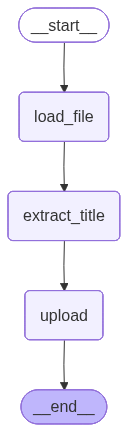

In [12]:
from langgraph.graph import StateGraph

builder = StateGraph(BlogState)

# Add nodes
builder.add_node("load_file", load_file_node)
builder.add_node("extract_title", extract_title_node)
builder.add_node("upload", upload_node)

# Flow
builder.set_entry_point("load_file")
builder.add_edge("load_file", "extract_title")
builder.add_edge("extract_title", "upload")

# Compile
graph = builder.compile()
graph

In [13]:
result = graph.invoke({
    "file_path": "blog.md",
    "content": "",
    "title": "",
    "response": None
})

print(result["response"])

✅ Uploaded Successfully
{'type_of': 'article', 'id': 3531282, 'title': 'State of Multimodal LLMs in 2026', 'description': 'State of Multimodal LLMs in 2026            Introduction to Multimodal LLMs   Multimodal...', 'readable_publish_date': 'Apr 21', 'slug': 'state-of-multimodal-llms-in-2026-3km1', 'path': '/kartik_jambucha_2e538749a/state-of-multimodal-llms-in-2026-3km1', 'url': 'https://dev.to/kartik_jambucha_2e538749a/state-of-multimodal-llms-in-2026-3km1', 'comments_count': 0, 'public_reactions_count': 0, 'collection_id': None, 'published_timestamp': '2026-04-21T10:01:57Z', 'language': 'en', 'subforem_id': 1, 'positive_reactions_count': 0, 'cover_image': None, 'social_image': 'https://dev-to-uploads.s3.amazonaws.com/uploads/articles/3otvb2z646ytpt1hl2rv.jpg', 'canonical_url': 'https://dev.to/kartik_jambucha_2e538749a/state-of-multimodal-llms-in-2026-3km1', 'created_at': '2026-04-21T10:01:57Z', 'edited_at': None, 'crossposted_at': None, 'published_at': '2026-04-21T10:01:57Z', 'last